
# TITLE: Decision Tree Classification using Iris Dataset
# AUTHOR: John Hosanna Mundlagiri
# DATE: 03.05. 2026
# DATASET: sklearn.datasets.load_iris()



In [ ]:
# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine learning tools from scikit-learn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Optional comparison model
from sklearn.ensemble import RandomForestClassifier

import sklearn


In [ ]:
# ============================================================
# 2. SET RANDOM SEEDS FOR REPRODUCIBILITY
# This ensures results are consistent every time the notebook runs
# ============================================================

np.random.seed(42)


# ============================================================
# 3. PRINT LIBRARY VERSIONS
# Helps ensure reproducibility of results
# ============================================================

print("Numpy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("Scikit-learn version:", sklearn.__version__)

Numpy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Scikit-learn version: 1.6.1


We used NumPy 2.0.2, Pandas 2.2.2, Matplotlib 3.10.0, and Scikit-learn 1.6.1. We reported library versions to ensure reproducibility and allow others to replicate the experiment using the same environment.

In [ ]:
# ============================================================
# 4. LOAD DATASET
# Iris dataset contains measurements of flowers.
# Features: sepal length, sepal width, petal length, petal width
# Target variable: species of iris flower
# ============================================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names


# Convert to DataFrame for easier exploration
df = pd.DataFrame(X, columns=feature_names)
df["species"] = y

print("\nDataset Preview")
print(df.head())


# ============================================================
# WHY THIS DATASET IS GOOD FOR DECISION TREES
# - Small structured dataset
# - Clear separations between classes
# - Interpretable features
# - Ideal for demonstrating tree splits
# ============================================================



Dataset Preview
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


We displayed the first rows of the Iris dataset to understand its structure. The dataset included sepal length, sepal width, petal length, petal width, and species as the target classification variable.

In [ ]:


# ============================================================
# 5. TRAIN TEST SPLIT
# Split dataset into training and testing sets
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))




Training samples: 105
Testing samples: 45


We divided the dataset into 105 training samples and 45 testing samples. The training data was used to build the decision tree model, while the testing data evaluated its predictive performance.

In [ ]:

# ============================================================
# 6. TRAIN BASIC DECISION TREE MODEL
# Default parameters are used initially
# ============================================================

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)



DecisionTreeClassifier(random_state=42)

In [ ]:

# ============================================================
# 7. MODEL PREDICTIONS
# ============================================================

y_pred_train = tree_model.predict(X_train)
y_pred_test = tree_model.predict(X_test)


In [ ]:
# ============================================================
# 8. MODEL ACCURACY
# Compare performance on training vs testing data
# ============================================================

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("\nTraining Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)


# ============================================================
# 9. CONFUSION MATRIX
# Shows classification performance for each class
# ============================================================

cm = confusion_matrix(y_test, y_pred_test)

print("\nConfusion Matrix")
print(cm)


Training Accuracy: 1.0
Testing Accuracy: 1.0

Confusion Matrix
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


We calculated training and testing accuracy after fitting the model. Both accuracies were 1.0, meaning the model correctly classified all samples and demonstrated excellent predictive performance on the dataset.

In [ ]:
# ============================================================
# 10. CLASSIFICATION REPORT
# Shows precision, recall, and F1-score
# ============================================================

print("\nClassification Report")
print(classification_report(y_test, y_pred_test, target_names=target_names))



Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



We generated a confusion matrix to evaluate classification performance. The matrix showed correct predictions for all three species classes with no misclassifications, indicating that the model performed perfectly.

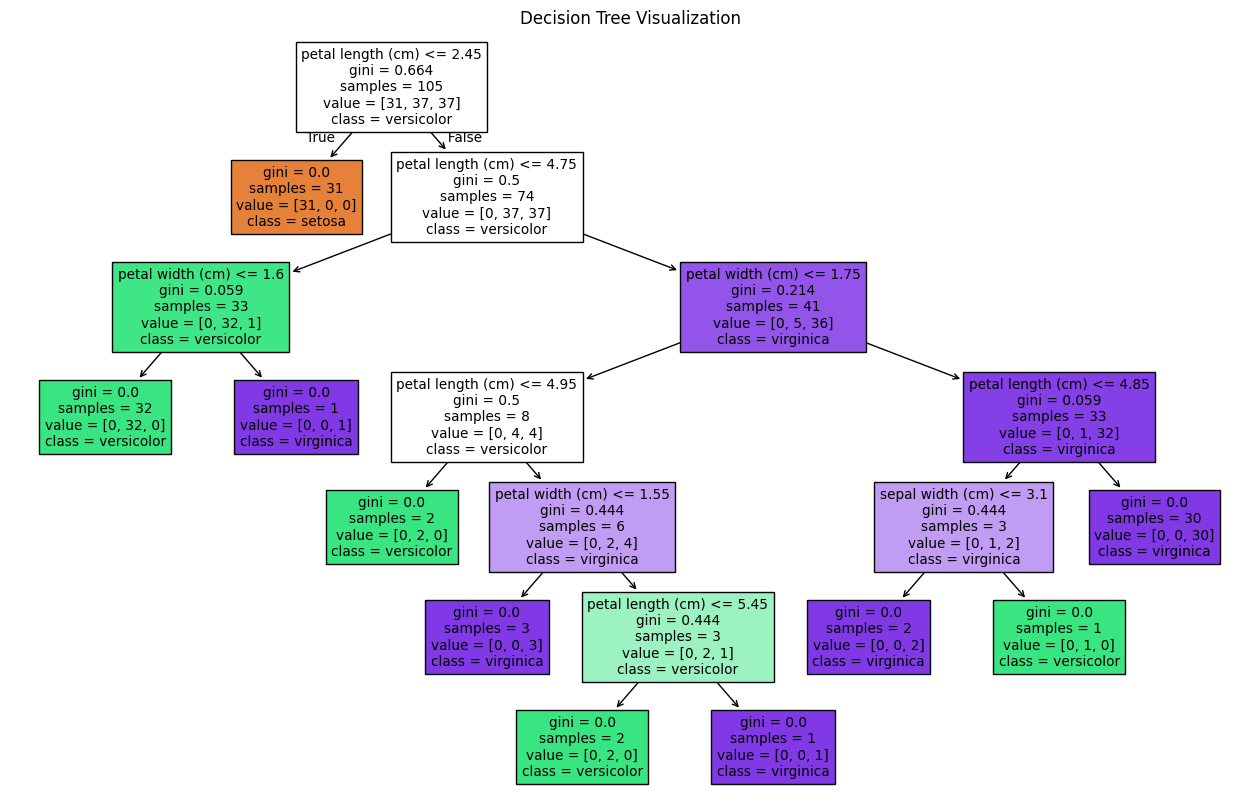

In [ ]:
# ============================================================
# 11. VISUALIZE THE DECISION TREE
# Each node shows:
# - Feature split
# - Threshold
# - Gini impurity
# - Number of samples
# - Class distribution
# ============================================================

plt.figure(figsize=(16,10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=target_names,
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()

We visualized the trained decision tree using a plot. The diagram displayed feature splits, thresholds, Gini impurity values, sample counts, and class distributions, helping us clearly understand how the model made classification decisions.

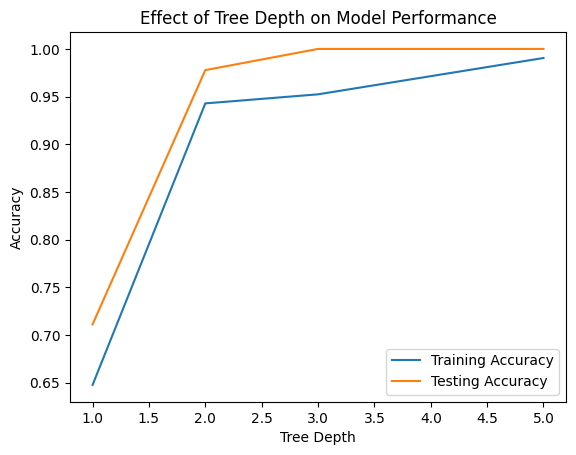

In [ ]:
# ============================================================
# 12. OVERFITTING & REGULARIZATION
# Train trees with different parameters
# ============================================================

depth_values = [1, 2, 3, 4, 5]

train_scores = []
test_scores = []

for depth in depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(accuracy_score(y_train, train_pred))
    test_scores.append(accuracy_score(y_test, test_pred))


# ============================================================
# PLOT MODEL PERFORMANCE
# ============================================================

plt.figure()

plt.plot(depth_values, train_scores, label="Training Accuracy")
plt.plot(depth_values, test_scores, label="Testing Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Model Performance")
plt.legend()

plt.show()


We plotted model performance to compare training and testing accuracy across different tree depths. This visualization helped us observe how increasing depth affected accuracy and revealed potential overfitting when training accuracy increased significantly.


Feature Importance
             Feature  Importance
0  sepal length (cm)    0.000000
1   sepal width (cm)    0.019110
2  petal length (cm)    0.893264
3   petal width (cm)    0.087626


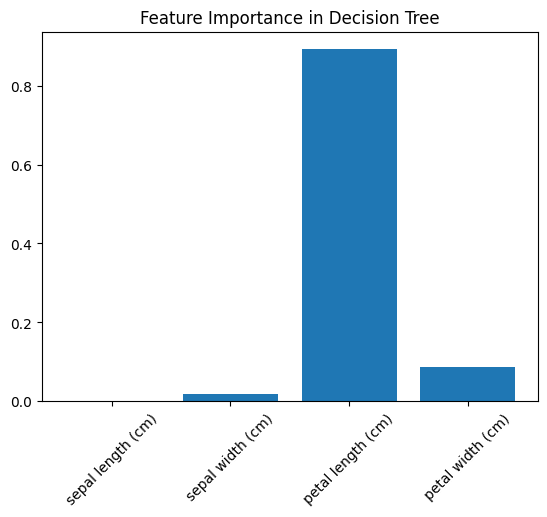

In [ ]:

# ============================================================
# 13. FEATURE IMPORTANCE
# Shows which features influence the model most
# ============================================================

importances = tree_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

print("\nFeature Importance")
print(feature_importance_df)


# ============================================================
# PLOT FEATURE IMPORTANCE
# ============================================================

plt.figure()

plt.bar(feature_names, importances)

plt.title("Feature Importance in Decision Tree")
plt.xticks(rotation=45)

plt.show()

We extracted feature importance values from the trained decision tree. Petal length was the most influential feature, followed by petal width, while sepal measurements contributed less to classification decisions.

In [ ]:

# ============================================================
# 14. OPTIONAL EXTENSION: RANDOM FOREST COMPARISON
# Random Forest is an ensemble method using many trees
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\nRandom Forest Accuracy:", rf_accuracy)



Random Forest Accuracy: 1.0


We trained a Random Forest model to compare performance with the decision tree. The Random Forest also achieved perfect accuracy, demonstrating strong predictive capability using an ensemble learning approach.

Model Interpretation Notes

In this project, we analyzed how decision trees classify data by splitting it using feature thresholds. Each split selected the feature and value that best separated the classes. We also examined Gini impurity, which measured how mixed the classes were in a node, helping determine the best split. During experimentation, we observed that deeper trees tended to memorize the training data, which could lead to overfitting. To address this issue, we applied regularization techniques such as limiting the tree depth using the max_depth parameter. Additionally, we evaluated feature importance to understand which variables contributed most to the model’s predictions and decision-making process.

Conclusion

Overall, the decision tree model provided an interpretable way to classify the dataset. The experiment showed that controlling model complexity helps prevent overfitting, while feature importance improves understanding of predictions. Decision trees are useful for interpretable machine learning tasks.

AI Assistance Log
We used AI to help check our work, verify code correctness, review outputs, confirm calculations, ensure visualizations were accurate, and validate interpretations of model performance, overfitting, and feature importance. AI assisted in reviewing the notebook and improving clarity and consistency throughout the project.